# Library 

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Get the dataset

In [3]:
df = pd.read_csv("IMDB_preprocessed.csv")

df.head()

,review,sentiment,label
0,one reviewers mention watch oz episode youll h...,positive,1
1,wonderful little production film technique una...,positive,1
2,think wonderful way spend time hot summer week...,positive,1
3,basically theres family little boy jake think ...,negative,0
4,petter matteis love time money visually stun f...,positive,1


# Train and test data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (40000,)
Test size: (10000,)


# Bayes classification

## One Hot Encoding

In [35]:
text_pipeline_bayes_one = Pipeline(
    steps=[
        ("encoding", CountVectorizer(binary=True,stop_words='english', ngram_range=(1, 2), max_features=2000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_one.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [36]:
y_pred_bayes_one = text_pipeline_bayes_one.predict(X_test)
y_proba_bayes_one = text_pipeline_bayes_one.predict_proba(X_test)

In [37]:
results_bayes_one = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_one,
    "predicted_probability_positive": y_proba_bayes_one[:,1]
})

results_bayes_one.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,8.518594e-03
1,0,1,9.023214e-01
2,1,1,9.946048e-01
3,0,0,9.028466e-03
4,0,0,9.018673e-05
5,0,0,1.547264e-03
6,0,0,4.709776e-05
7,0,1,5.442123e-01
8,0,0,3.347618e-01
9,0,0,2.632326e-08


#### Accuracy, Precision, Recall, F1-score of OneHotEncoding

##### Testing

In [38]:
accuracy_bayes_one = accuracy_score(y_test, y_pred_bayes_one)
precision_bayes_one = precision_score(y_test, y_pred_bayes_one)
recall_bayes_one = recall_score(y_test, y_pred_bayes_one)
f1_bayes_one = f1_score(y_test, y_pred_bayes_one)

print(f"Accuracy:  {accuracy_bayes_one}")
print(f"Precision: {precision_bayes_one}")
print(f"Recall:    {recall_bayes_one}")
print(f"F1-score:  {f1_bayes_one}")

Accuracy:  0.8433
Precision: 0.8406429847191903
Recall:    0.8472
F1-score:  0.8439087558521765


In [39]:
print(classification_report(
    y_test,
    y_pred_bayes_one,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84      5000
    Positive       0.84      0.85      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



##### Trainning

In [40]:
y_train_bayes_one = text_pipeline_bayes_one.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_bayes_one)
print(f"Training accuracy: {train_accuracy}")

train_precision = precision_score(y_train, y_train_bayes_one)
print(f"Training precision: {train_precision}")

train_recall = recall_score(y_train,y_train_bayes_one)
print(f"Training recall: {train_recall}")

train_f1_score = f1_score(y_train,y_train_bayes_one)
print(f"Training F1-score: {train_f1_score}")


Training accuracy: 0.8452
Training precision: 0.841005630741875
Training recall: 0.85135
Training F1-score: 0.8461462008646822


#### Error analysis

In [41]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_bayes_one
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
39791,story bride fair amuse engage one filmmakers c...,0,1
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectations watch friends ...,1,0
40714,little quentin seem master art cake eat itas u...,0,1
31882,film list make film available something weird ...,0,1
7266,farrah fawcett give award nominate performance...,1,0
4142,movie gung ho story carlsons makin island raid...,0,1
29270,cafe lumiere beautifully photograph nullity un...,0,1
42615,read many review movie love hate apparently mu...,1,0
11840,know brad linaweaver florida state u early ins...,0,1


#### Train and test score

In [42]:
train_accuracy = accuracy_score(y_train, y_train_bayes_one)
test_accuracy = accuracy_score(y_test, y_pred_bayes_one)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")



Training accuracy: 0.8452
Testing accuracy: 0.8433


#### Confusion matrix of OneHotEncoding

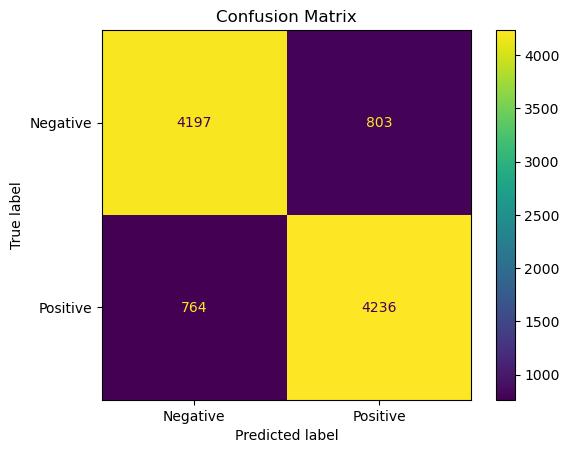

In [43]:
cm_bayes_one = confusion_matrix(y_test, y_pred_bayes_one)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_one,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Bag of Words

In [44]:
text_pipeline_bayes_bag = Pipeline(
    steps=[
        ("encoding", CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=2000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_bag.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [45]:
y_pred_bayes_bag = text_pipeline_bayes_bag.predict(X_test)
y_proba_bayes_bag = text_pipeline_bayes_bag.predict_proba(X_test)

In [46]:
results_bayes_bag = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_bag,
    "predicted_probability_positive": y_proba_bayes_bag[:,1]
})

results_bayes_bag.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,3.067779e-03
1,0,1,9.266289e-01
2,1,1,9.863409e-01
3,0,0,4.147925e-03
4,0,0,2.773203e-05
5,0,0,1.241847e-03
6,0,0,1.681845e-06
7,0,1,5.469586e-01
8,0,0,3.633632e-01
9,0,0,4.160733e-12


#### Accuracy, Precision, Recall, F1-score of Bag of Words

##### Testing

In [47]:
accuracy_bayes_bag = accuracy_score(y_test, y_pred_bayes_bag)
precision_bayes_bag = precision_score(y_test, y_pred_bayes_bag)
recall_bayes_bag = recall_score(y_test, y_pred_bayes_bag)
f1_bayes_bag = f1_score(y_test, y_pred_bayes_bag)

print(f"Accuracy:  {accuracy_bayes_bag}")
print(f"Precision: {precision_bayes_bag}")
print(f"Recall:    {recall_bayes_bag}")
print(f"F1-score:  {f1_bayes_bag}")

Accuracy:  0.834
Precision: 0.8313492063492064
Recall:    0.838
F1-score:  0.8346613545816733


In [48]:
print(classification_report(
    y_test,
    y_pred_bayes_bag,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83      5000
    Positive       0.83      0.84      0.83      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



##### Training

In [49]:
y_train_bayes_bag = text_pipeline_bayes_bag.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_bayes_bag)
print(f"Training accuracy: {train_accuracy}")


train_precision = precision_score(y_train, y_train_bayes_bag)
print(f"Training precision: {train_precision}")

train_recall = recall_score(y_train,y_train_bayes_bag)
print(f"Training recall: {train_recall}")

train_f1_score = f1_score(y_train,y_train_bayes_bag)
print(f"Training F1-score: {train_f1_score}")


Training accuracy: 0.8379
Training precision: 0.8337283950617284
Training recall: 0.84415
Training F1-score: 0.8389068322981367


#### Error analysis

In [50]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_bayes_bag
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
39791,story bride fair amuse engage one filmmakers c...,0,1
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectations watch friends ...,1,0
40714,little quentin seem master art cake eat itas u...,0,1
31882,film list make film available something weird ...,0,1
1591,great movie tho cast especially kid admirably ...,1,0
4142,movie gung ho story carlsons makin island raid...,0,1
29270,cafe lumiere beautifully photograph nullity un...,0,1
42615,read many review movie love hate apparently mu...,1,0
11840,know brad linaweaver florida state u early ins...,0,1


#### Train and test score

In [51]:
train_accuracy = accuracy_score(y_train, y_train_bayes_bag)
test_accuracy = accuracy_score(y_test, y_pred_bayes_bag)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")


Training accuracy: 0.8379
Testing accuracy: 0.834


#### Confusion matrix of Bag of Words

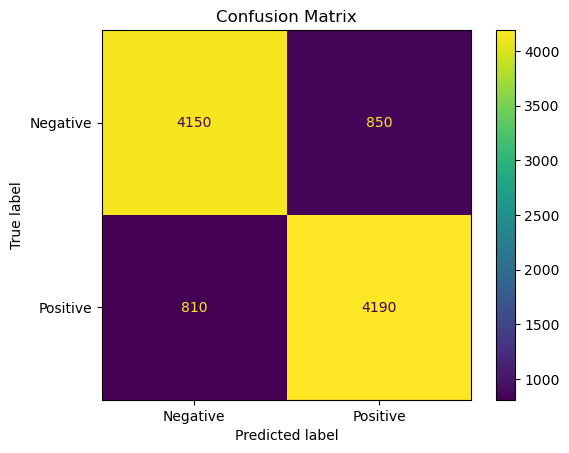

In [52]:
cm_bayes_bag = confusion_matrix(y_test, y_pred_bayes_bag)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_bag,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## TF-IDF

In [53]:
text_pipeline_bayes_tfidf = Pipeline(
    steps=[
        ("encoding", TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=2000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_tfidf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [54]:
y_pred_bayes_tfidf = text_pipeline_bayes_tfidf.predict(X_test)
y_proba_bayes_tfidf = text_pipeline_bayes_tfidf.predict_proba(X_test)

In [55]:
results_bayes_tfidf = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_tfidf,
    "predicted_probability_positive": y_proba_bayes_tfidf[:,1]
})

results_bayes_tfidf.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,0.295238
1,0,1,0.626495
2,1,1,0.666591
3,0,0,0.333649
4,0,0,0.181141
5,0,0,0.246493
6,0,0,0.214400
7,0,1,0.534207
8,0,0,0.486412
9,0,0,0.134468


#### Accuracy, Precision, Recall, F1-score of TF - IDF

##### Testing

In [56]:
accuracy_bayes_tfidf = accuracy_score(y_test, y_pred_bayes_tfidf)
precision_bayes_tfidf = precision_score(y_test, y_pred_bayes_tfidf)
recall_bayes_tfidf = recall_score(y_test, y_pred_bayes_tfidf)
f1_bayes_tfidf = f1_score(y_test, y_pred_bayes_tfidf)

print(f"Accuracy:  {accuracy_bayes_tfidf}")
print(f"Precision: {precision_bayes_tfidf}")
print(f"Recall:    {recall_bayes_tfidf}")
print(f"F1-score:  {f1_bayes_tfidf}")

Accuracy:  0.8429
Precision: 0.8331066640761609
Recall:    0.8576
F1-score:  0.84517591406327


In [57]:
print(classification_report(
    y_test,
    y_pred_bayes_tfidf,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.85      0.83      0.84      5000
    Positive       0.83      0.86      0.85      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



##### Trainning

In [58]:
y_train_bayes_tfidf = text_pipeline_bayes_tfidf.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_bayes_tfidf)
print(f"Training accuracy: {train_accuracy}")

train_precision = precision_score(y_train, y_train_bayes_tfidf)
print(f"Training precision: {train_precision}")

train_recall = recall_score(y_train,y_train_bayes_tfidf)
print(f"Training recall: {train_recall}")

train_f1_score = f1_score(y_train,y_train_bayes_tfidf)
print(f"Training F1-score: {train_f1_score}")


Training accuracy: 0.847775
Training precision: 0.8380230354279049
Training recall: 0.8622
Training F1-score: 0.8499396209675432


#### Error analysis

In [59]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_bayes_tfidf
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
39791,story bride fair amuse engage one filmmakers c...,0,1
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectations watch friends ...,1,0
40714,little quentin seem master art cake eat itas u...,0,1
31882,film list make film available something weird ...,0,1
44196,level ring ring still good japanese horror fli...,1,0
1591,great movie tho cast especially kid admirably ...,1,0
4142,movie gung ho story carlsons makin island raid...,0,1
42615,read many review movie love hate apparently mu...,1,0
11840,know brad linaweaver florida state u early ins...,0,1


#### Train and test score

In [60]:
train_accuracy = accuracy_score(y_train, y_train_bayes_tfidf)
test_accuracy = accuracy_score(y_test, y_pred_bayes_tfidf)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")



Training accuracy: 0.847775
Testing accuracy: 0.8429


#### Confusion matrix of TF-IDF

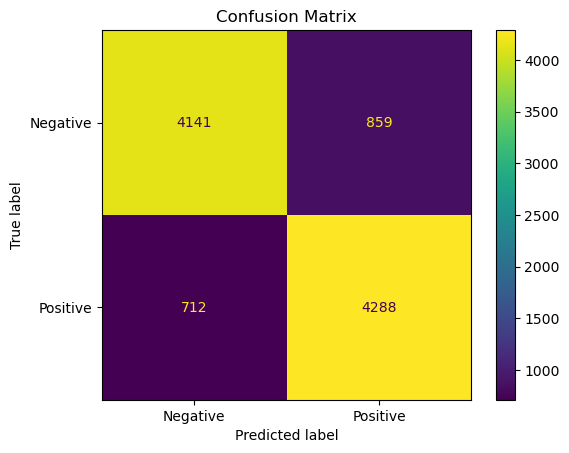

In [61]:
cm_bayes_tfidf = confusion_matrix(y_test, y_pred_bayes_tfidf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_tfidf,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()